In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
df= pd.read_excel("k-means.xlsx")

In [3]:
df

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


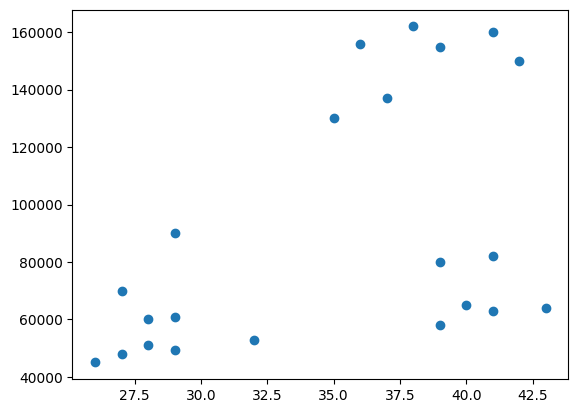

In [4]:
plt.scatter(x=df.loc[:,'Age'],y=df.loc[:,'Income'])

In [5]:
from sklearn.cluster import KMeans

In [6]:
from sklearn.preprocessing import StandardScaler 

In [7]:
df = df.astype({df.columns[1]: 'float64', df.columns[2]: 'float64'})
st=StandardScaler()
df.iloc[:,1]=st.fit_transform(df.iloc[:,[1]])
df.iloc[:,2]=st.fit_transform(df.iloc[:,[2]])

In [8]:
df

,Name,Age,Income
0,Rob,-1.356055,-0.480684
1,Michael,-1.009157,-0.010159
2,Mohan,-1.009157,-0.692421
3,Ismail,-1.182606,-0.715947
4,Kory,1.245679,1.401417
5,Gautam,0.725332,1.519048
6,David,1.072230,1.636679
7,Andrea,0.551883,1.683732
8,Brad,0.204985,1.542574
9,Angelina,0.031536,0.930891


In [9]:
km= KMeans(n_clusters=3)
ans= km.fit_predict(df.iloc[:,1:])

In [10]:
ans

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [11]:
df.loc[:,'target']=ans

In [12]:
df

,Name,Age,Income,target
0,Rob,-1.356055,-0.480684,1
1,Michael,-1.009157,-0.010159,1
2,Mohan,-1.009157,-0.692421,1
3,Ismail,-1.182606,-0.715947,1
4,Kory,1.245679,1.401417,0
5,Gautam,0.725332,1.519048,0
6,David,1.072230,1.636679,0
7,Andrea,0.551883,1.683732,0
8,Brad,0.204985,1.542574,0
9,Angelina,0.031536,0.930891,0


In [17]:
df[df.loc[:,'target']==0].Age

4     1.245679
5     0.725332
6     1.072230
7     0.551883
8     0.204985
9     0.031536
10    0.378434
Name: Age, dtype: float64

In [14]:
a=km.cluster_centers_
a

array([[ 0.60143983,  1.40141653],
       [-1.1247901 , -0.74862223],
       [ 0.98550535, -0.51205261]])

In [15]:
a[:,0]

array([ 0.60143983, -1.1247901 ,  0.98550535])

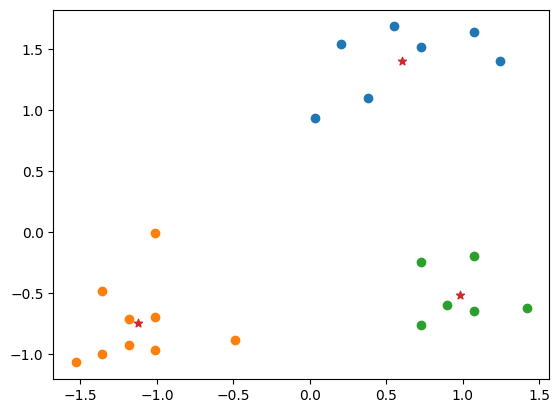

In [16]:
plt.scatter(x= df[df.loc[:,'target']==0].Age,y=df[df.loc[:,'target']==0].Income)
plt.scatter(x= df[df.loc[:,'target']==1].Age,y=df[df.loc[:,'target']==1].Income)
plt.scatter(x= df[df.loc[:,'target']==2].Age,y=df[df.loc[:,'target']==2].Income)
plt.scatter(x=a[:,0],y=a[:,1], marker='*')
